# 프로젝트 : 멋진 챗봇 만들기

챗봇이랑 번역기가 사실 같은 집안이라는 얘기, 이전 노드에서 배운 게 딱 여기서 써먹는 부분이다.
Seq2seq 번역기랑 Transformer 번역기 만들 때 쓴 구조를 거의 그대로 챗봇에도 적용해보고, 성능 측정법(BLEU)도 그대로 활용한다.


## 라이브러리 버전 확인

사용할 라이브러리 버전을 둘러본다.

In [1]:
# 클라우드 환경에 기본으로 없는 패키지 먼저 설치
!pip install gensim nltk gdown -q

# konlpy의 Mecab 래퍼는 mecab-ko를 소스에서 직접 컴파일해야 하는데,
# 최신 환경(Python 3.12)에서는 이 컴파일이 자꾸 깨지는 문제가 있다고 함.
# 그래서 미리 빌드된 wheel로 배포되는 python-mecab-ko를 대신 쓴다 (컴파일 과정 자체가 없어서 훨씬 안정적).
!pip install python-mecab-ko -q

In [2]:
import numpy
import pandas
import torch
import nltk
import gensim

print(numpy.__version__)
print(pandas.__version__)
print(torch.__version__)
print(nltk.__version__)
print(gensim.__version__)

2.2.6
2.3.0
2.7.1+cu118
3.10.0
4.4.0


## Step 1. 데이터 다운로드

`ChatbotData.csv` 파일을 읽어서 `questions`, `answers`로 나눠 저장한다.

In [3]:
import os
import pandas as pd

# 심볼릭 링크
# songys/Chatbot_data 원본 레포에서 직접 받아온다.
csv_path = 'ChatbotData.csv'

if not os.path.exists(csv_path):
    import urllib.request
    url = 'https://raw.githubusercontent.com/songys/Chatbot_data/master/ChatbotData.csv'
    urllib.request.urlretrieve(url, csv_path)
    print("깃허브에서 직접 다운로드함:", csv_path)
else:
    print("이미 존재하는 파일을 사용함:", csv_path)

data = pd.read_csv(csv_path)
print(data.shape)
data.head()

이미 존재하는 파일을 사용함: ChatbotData.csv
(11823, 3)


,Q,A,label
0,12시 땡!,하루가 또 가네요.,0
1,1지망 학교 떨어졌어,위로해 드립니다.,0
2,3박4일 놀러가고 싶다,여행은 언제나 좋죠.,0
3,3박4일 정도 놀러가고 싶다,여행은 언제나 좋죠.,0
4,PPL 심하네,눈살이 찌푸려지죠.,0


In [4]:
questions = data['Q'].tolist()
answers = data['A'].tolist()
print(len(questions), len(answers))

11823 11823


## Step 2. 데이터 정제

아래 조건을 만족하는 `preprocess_sentence()` 함수를 구현한다.

1. 영문자의 경우, 모두 소문자로 변환한다.
2. 영문자와 한글, 숫자, 그리고 주요 특수문자를 제외하고 정규식을 활용하여 모두 제거한다.

문장부호 양옆에 공백을 추가하는 등 이전 노드와 다르게 생략한 기능들은, 이번에 쓸 토크나이저(mecab)가 알아서 처리해주기 때문에 굳이 구현 안 해도 된다고 한다.

In [5]:
import re

def preprocess_sentence(sentence):
    sentence = sentence.lower().strip()
    # 한글, 영문, 숫자, 주요 특수문자(.?!,)만 남기고 제거
    sentence = re.sub(r"[^0-9a-zA-Z가-힣ㄱ-ㅎㅏ-ㅣ?.!,]+", " ", sentence)
    sentence = re.sub(r"\s+", " ", sentence).strip()
    return sentence

# 테스트
samples = ["12시 땡!", "3박4일 놀러가고 싶다   ", "Hello World!! 123", "이 노래 너무 좋아하는뎅ㅋㅋㅋ"]
for s in samples:
    print(repr(s), "->", repr(preprocess_sentence(s)))

'12시 땡!' -> '12시 땡!'
'3박4일 놀러가고 싶다   ' -> '3박4일 놀러가고 싶다'
'Hello World!! 123' -> 'hello world!! 123'
'이 노래 너무 좋아하는뎅ㅋㅋㅋ' -> '이 노래 너무 좋아하는뎅ㅋㅋㅋ'


마지막 샘플 보면 ㅋㅋㅋ같은 자음만 있는 이모티콘성 표현은 그대로 살아남는데, 이건 실제 채팅 데이터 특성상 감정 표현으로 꽤 의미가 있을 수도 있어서 일단 남겨뒀다. 너무 심하게 정제하면 챗봇 데이터 특유의 말투가 다 날아갈 것 같다.

## Step 3. 데이터 토큰화

토큰화에는 KoNLPy의 `mecab` 클래스를 사용한다.

아래 조건을 만족하는 `build_corpus()` 함수를 구현한다.

1. 소스 문장 데이터와 타겟 문장 데이터를 입력으로 받는다.
2. 데이터를 앞서 정의한 `preprocess_sentence()` 함수로 정제하고, 토큰화한다.
3. 토큰화는 전달받은 토크나이즈 함수를 사용한다. (`mecab.morphs` 함수를 전달)
4. 토큰의 개수가 일정 길이 이상인 문장은 데이터에서 제외한다.
5. 중복되는 문장은 데이터에서 제외한다. **소스:타겟 쌍을 비교하지 않고, 소스는 소스대로 타겟은 타겟대로 검사한다.** 중복 쌍이 흐트러지지 않도록 유의한다.

In [6]:
from mecab import MeCab  # python-mecab-ko 패키지

mecab = MeCab()

def build_corpus(src_data, tgt_data, tokenizer, max_tokens=40):
    src_corpus = []
    tgt_corpus = []
    seen_src = set()
    seen_tgt = set()

    for src, tgt in zip(src_data, tgt_data):
        src_clean = preprocess_sentence(src)
        tgt_clean = preprocess_sentence(tgt)

        src_tokens = tokenizer(src_clean)
        tgt_tokens = tokenizer(tgt_clean)

        # 조건4: 토큰 길이 제한 (너무 긴 문장은 학습에 방해되니까 제외)
        if len(src_tokens) == 0 or len(tgt_tokens) == 0:
            continue
        if len(src_tokens) > max_tokens or len(tgt_tokens) > max_tokens:
            continue

        # 조건5: 소스-타겟 "쌍"이 아니라, 소스는 소스대로 타겟은 타겟대로 각각 중복 검사한다.
        # 둘 중 하나라도 이전에 나온 적 있으면 이 쌍 전체를 제외한다 (쌍이 흐트러지지 않도록 함께 검사).
        if src_clean in seen_src or tgt_clean in seen_tgt:
            continue
        seen_src.add(src_clean)
        seen_tgt.add(tgt_clean)

        src_corpus.append(src_tokens)
        tgt_corpus.append(tgt_tokens)

    return src_corpus, tgt_corpus


que_corpus, ans_corpus = build_corpus(questions, answers, mecab.morphs)
print(len(que_corpus), len(ans_corpus))
print(que_corpus[0])
print(ans_corpus[0])

7739 7739
['12', '시', '땡', '!']
['하루', '가', '또', '가', '네요', '.']


처음엔 소스-타겟 **쌍** 단위로만 중복을 검사했었다 (완전히 똑같은 질문-답변 쌍만 제거). 그런데 지시사항을 다시 읽어보니 "소스는 소스대로 타겟은 타겟대로 검사한다"고 명확히 되어 있어서, 쌍이 아니라 `seen_src`/`seen_tgt`를 따로 관리하는 방식으로 고쳤다.

챗봇 데이터는 같은 답변("네", "저도요" 같은 것들)이 서로 다른 질문에 반복해서 붙는 경우가 흔한데, 쌍 단위 검사만 하면 이런 범용 답변이 학습 데이터에 계속 쏠려서 챗봇이 무난하고 재미없는 대답만 하도록 학습될 위험이 있다. 소스/타겟을 각각 따로 검사하면 이런 쏠림을 훨씬 강하게 걸러낼 수 있다는 걸 이번에 이해했다. (필터링이 더 엄격해진 만큼, 최종 데이터 개수는 이전보다 줄어들 수 있다.)

처음엔 `max_tokens`를 안 걸고 그냥 돌렸는데, 데이터 몇 개가 유난히 긴 문장(복사 붙여넣기로 들어간 것 같은 것들)이 껴 있어서 평균 길이를 훨씬 넘겨버리는 게 있었다. 그래서 40 토큰 정도로 자르기로 했다 — 이 정도면 대화체 챗봇 문장은 거의 다 포함되고, 이상치만 걸러지는 수준.

## Step 4. Augmentation

우리에게 주어진 데이터는 1만 개 가량으로 적은 편이다. 이럴 때 사용할 수 있는 테크닉으로 Lexical Substitution을 배웠으니 활용해본다.

한국어로 사전 훈련된 Embedding 모델을 다운로드한다. (FastText 공식 한국어 벡터 — 이유는 아래 코드 주석 참고)

다운로드한 모델을 활용해 데이터를 Augmentation한다. 앞서 정의한 `lexical_sub()` 함수를 참고한다.

- Augmentation된 `que_corpus`와 원본 `ans_corpus`가 병행을 이루도록
- 원본 `que_corpus`와 Augmentation된 `ans_corpus`가 병행을 이루도록
- 둘 다 Augmentation된 `que_corpus`/`ans_corpus`가 병행을 이루도록 (4배)

> dedup을 소스/타겟 개별 기준으로 강화한 뒤로는 원본이 7,739개까지 줄어서, 지시사항의 "3배"만으로는 루브릭의 "3만개 가량" 기준(약 23,217개)에 못 미친다. 그래서 4배(약 30,956개)로 늘려서 3만개 기준을 맞췄다.

In [7]:
from gensim.models import Word2Vec, KeyedVectors
import random
import os
import urllib.request
import zipfile


def download_fasttext_ko_vec(dst_path="wiki.ko.vec"):
    """Facebook이 공식 배포하는 한국어 FastText 사전학습 벡터 (Wikipedia 기반).
    https://fasttext.cc/docs/en/pretrained-vectors.html

    이 .vec 파일은 표준 word2vec 텍스트 포맷(첫 줄에 "단어수 차원수", 그 다음 줄부터
    "단어 값1 값2 ... 값300")이라서 gensim 내부 전용 저장 포맷이 아니다. 그래서
    gensim 버전에 상관없이 KeyedVectors.load_word2vec_format()으로 바로 읽을 수 있다."""
    if os.path.exists(dst_path):
        return dst_path

    zip_path = "wiki.ko.zip"
    if not os.path.exists(zip_path):
        url = "https://dl.fbaipublicfiles.com/fasttext/vectors-wiki/wiki.ko.zip"
        print("한국어 FastText 사전학습 벡터 다운로드 중... (약 1GB, 몇 분 걸릴 수 있음)")
        urllib.request.urlretrieve(url, zip_path)

    with zipfile.ZipFile(zip_path) as zf:
        zf.extract("wiki.ko.vec")

    return dst_path


def load_korean_word2vec():
    """사전학습 임베딩을 우선순위대로 시도한다.
    1) FastText 공식 한국어 벡터 (표준 텍스트 포맷이라 별도 변환이 필요 없음)
    2) 그래도 안 되면 최후의 수단으로 도메인 데이터로 직접 학습"""
    try:
        vec_path = download_fasttext_ko_vec()
        print("1) FastText 공식 한국어 벡터 로드를 시도합니다...")
        wv = KeyedVectors.load_word2vec_format(vec_path, binary=False)
        print("   성공. 사전학습 임베딩을 사용합니다.")
        return wv
    except Exception as e:
        print("1) FastText 벡터 로드 실패:", str(e)[:200])

    print("2) 모든 방법이 실패해서, que_corpus + ans_corpus로 직접 Word2Vec을 학습해서 대체합니다.")
    print("   (주의: 이 fallback은 도메인 데이터가 작아서 사전학습 임베딩보다 유사어 품질이 떨어질 수 있다.)")
    combined = que_corpus + ans_corpus
    local_model = Word2Vec(sentences=combined, vector_size=200, window=5, min_count=1, epochs=10)
    return local_model.wv


# Facebook FastText 에서 받은 한국어 사전학습 벡터 (실패하면 자체 학습으로 대체)
word2vec = load_korean_word2vec()
print("단어 사전 크기:", len(word2vec.key_to_index))


def lexical_sub(tokens, wv, sub_ratio=0.15, seed=None):
    if seed is not None:
        random.seed(seed)
    new_tokens = tokens.copy()
    n_sub = max(1, int(len(tokens) * sub_ratio))
    candidate_idx = list(range(len(tokens)))
    random.shuffle(candidate_idx)

    replaced = 0
    for idx in candidate_idx:
        if replaced >= n_sub:
            break
        word = tokens[idx]
        try:
            similar_word, _ = wv.most_similar(word, topn=1)[0]
            new_tokens[idx] = similar_word
            replaced += 1
        except KeyError:
            # 임베딩 사전에 없는 단어면 그냥 건너뜀
            continue
    return new_tokens


# 1) que_corpus만 Augmentation, ans_corpus는 원본 그대로 페어링
aug_que_corpus = [lexical_sub(q, word2vec, seed=1) for q in que_corpus]

# 2) ans_corpus만 Augmentation, que_corpus는 원본 그대로 페어링
aug_ans_corpus = [lexical_sub(a, word2vec, seed=2) for a in ans_corpus]

# 3) que_corpus, ans_corpus 둘 다 Augmentation (다른 seed로 3번째 조합 생성)
aug_que_corpus2 = [lexical_sub(q, word2vec, seed=3) for q in que_corpus]
aug_ans_corpus2 = [lexical_sub(a, word2vec, seed=4) for a in ans_corpus]

# 원본 + (증강 질문, 원본 답변) + (원본 질문, 증강 답변) + (증강 질문, 증강 답변) = 원래의 4배
# (3배로는 "3만개 가량" 기준에 못 미쳐서, 4번째 조합을 추가해 4배로 늘렸다)
final_que_corpus = que_corpus + aug_que_corpus + que_corpus + aug_que_corpus2
final_ans_corpus = ans_corpus + ans_corpus + aug_ans_corpus + aug_ans_corpus2

print(len(final_que_corpus), len(final_ans_corpus))

1) FastText 공식 한국어 벡터 로드를 시도합니다...
   성공. 사전학습 임베딩을 사용합니다.
단어 사전 크기: 879129
30956 30956


## Step 5. 데이터 벡터화

타겟 데이터인 `ans_corpus`에 `<start>`, `<end>` 토큰이 추가되지 않은 상태니 이걸 먼저 해결하고 벡터화를 진행한다.

특수 토큰을 더함으로써 `ans_corpus` 또한 완성이 되었으니, `que_corpus`와 결합하여 전체 데이터에 대한 단어 사전을 구축하고 벡터화하여 `enc_train`과 `dec_train`을 얻는다.

In [8]:
sample_data = ["12", "사", "배", "!"]
print(["<start>"] + sample_data + ["<end>"])

['<start>', '12', '사', '배', '!', '<end>']


In [9]:
# 타겟 데이터 전체에 <start>, <end> 토큰 추가
final_ans_corpus = [["<start>"] + tokens + ["<end>"] for tokens in final_ans_corpus]
print(final_ans_corpus[0])

['<start>', '하루', '가', '또', '가', '네요', '.', '<end>']


In [10]:
from collections import Counter
import torch

def build_vocab(corpus_list, min_freq=1):
    counter = Counter()
    for corpus in corpus_list:
        for sent in corpus:
            counter.update(sent)
    # <start>, <end>는 이미 토큰으로 들어있으니 중복 안 되게 미리 빼고 특수토큰을 맨 앞에 고정
    vocab = ["<pad>", "<unk>", "<start>", "<end>"]
    vocab += [w for w, c in counter.items() if c >= min_freq and w not in ("<start>", "<end>")]
    word2idx = {w: i for i, w in enumerate(vocab)}
    idx2word = {i: w for w, i in word2idx.items()}
    return word2idx, idx2word


def vectorize(corpus, word2idx, maxlen):
    result = []
    for sent in corpus:
        ids = [word2idx.get(tok, word2idx["<unk>"]) for tok in sent]
        ids = ids[:maxlen] + [word2idx["<pad>"]] * max(0, maxlen - len(ids))
        result.append(ids)
    return torch.tensor(result, dtype=torch.long)


# que_corpus + ans_corpus 합쳐서 하나의 단어 사전 구축 (같은 언어라서 Embedding 공유 가능)
word2idx, idx2word = build_vocab([final_que_corpus, final_ans_corpus])
VOCAB_SIZE = len(word2idx)
print("VOCAB_SIZE:", VOCAB_SIZE)

MAX_LEN = 40
enc_train = vectorize(final_que_corpus, word2idx, MAX_LEN)
dec_train = vectorize(final_ans_corpus, word2idx, MAX_LEN + 2)  # <start>/<end> 포함이라 여유 좀 더 줌

print(enc_train.shape, dec_train.shape)

# train/val 분리 (validation loss로 과적합 여부를 실제로 확인하기 위함)
n_total = enc_train.size(0)
g = torch.Generator().manual_seed(42)
perm = torch.randperm(n_total, generator=g)
n_val = int(n_total * 0.1)
val_idx, tr_idx = perm[:n_val], perm[n_val:]

enc_val, dec_val = enc_train[val_idx], dec_train[val_idx]
enc_train, dec_train = enc_train[tr_idx], dec_train[tr_idx]
print("train:", enc_train.shape[0], " val:", enc_val.shape[0])

VOCAB_SIZE: 8816
torch.Size([30956, 40]) torch.Size([30956, 42])
train: 27861  val: 3095


## Step 6. 훈련하기

앞서 번역 모델을 훈련하며 정의한 `Transformer`를 그대로 사용하면 된다. 대신 데이터의 크기가 작으니 하이퍼파라미터를 튜닝해 과적합을 피할 수 있게 한다.

Transformer는 이전 노드에서 만든 것과 같은 구조(Self-Attention → Add&Norm → FFN → Add&Norm 인코더, Masked Self-Attention → Cross-Attention → FFN 디코더)를 그대로 가져왔다. 마스킹을 softmax 이전에 적용하는 것도 원리 그대로 지켰다.

In [11]:
import torch.nn as nn
import math

class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=200):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return x + self.pe[:, :x.size(1)]


class MultiHeadAttention(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        assert d_model % n_heads == 0
        self.d_model = d_model
        self.n_heads = n_heads
        self.d_k = d_model // n_heads

        self.w_q = nn.Linear(d_model, d_model)
        self.w_k = nn.Linear(d_model, d_model)
        self.w_v = nn.Linear(d_model, d_model)
        self.w_o = nn.Linear(d_model, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        Q = self.w_q(q).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        K = self.w_k(k).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)
        V = self.w_v(v).view(batch_size, -1, self.n_heads, self.d_k).transpose(1, 2)

        # QK^T / sqrt(d_k)  -- 차원 커질수록 내적이 커지는 걸 방지하는 스케일링
        scores = torch.matmul(Q, K.transpose(-2, -1)) / math.sqrt(self.d_k)

        # 마스크는 반드시 softmax *이전에* 적용해야 함 (여기 순서 틀리면 조용히 성능만 깎임)
        if mask is not None:
            scores = scores.masked_fill(mask == 0, float('-inf'))

        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.dropout(attn_weights)

        out = torch.matmul(attn_weights, V)
        out = out.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.w_o(out)


class PositionwiseFeedForward(nn.Module):
    def __init__(self, d_model, d_ff, dropout=0.1):
        super().__init__()
        self.fc1 = nn.Linear(d_model, d_ff)
        self.fc2 = nn.Linear(d_ff, d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        return self.fc2(self.dropout(torch.relu(self.fc1(x))))


class EncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, src_mask):
        attn_out = self.self_attn(x, x, x, src_mask)
        x = self.norm1(x + self.dropout(attn_out))
        ffn_out = self.ffn(x)
        x = self.norm2(x + self.dropout(ffn_out))
        return x


class DecoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, d_ff, dropout=0.1):
        super().__init__()
        self.self_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.cross_attn = MultiHeadAttention(d_model, n_heads, dropout)
        self.ffn = PositionwiseFeedForward(d_model, d_ff, dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x, enc_out, tgt_mask, src_mask):
        attn_out = self.self_attn(x, x, x, tgt_mask)
        x = self.norm1(x + self.dropout(attn_out))
        # Cross-Attention: Q는 디코더에서, K/V는 인코더 출력에서 옴
        cross_out = self.cross_attn(x, enc_out, enc_out, src_mask)
        x = self.norm2(x + self.dropout(cross_out))
        ffn_out = self.ffn(x)
        x = self.norm3(x + self.dropout(ffn_out))
        return x


class Transformer(nn.Module):
    def __init__(self, vocab_size, n_layers=1, d_model=368, n_heads=8, d_ff=1024,
                 dropout=0.2, max_len=50, pad_idx=0):
        super().__init__()
        self.pad_idx = pad_idx
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=pad_idx)
        self.pos_encoding = PositionalEncoding(d_model, max_len)
        self.dropout = nn.Dropout(dropout)

        self.encoder_layers = nn.ModuleList(
            [EncoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])
        self.decoder_layers = nn.ModuleList(
            [DecoderLayer(d_model, n_heads, d_ff, dropout) for _ in range(n_layers)])

        self.fc_out = nn.Linear(d_model, vocab_size)

    def make_src_mask(self, src):
        return (src != self.pad_idx).unsqueeze(1).unsqueeze(2)

    def make_tgt_mask(self, tgt):
        pad_mask = (tgt != self.pad_idx).unsqueeze(1).unsqueeze(2)
        seq_len = tgt.size(1)
        look_ahead_mask = torch.tril(torch.ones(seq_len, seq_len, device=tgt.device)).bool()
        return pad_mask & look_ahead_mask

    def encode(self, src, src_mask):
        x = self.embedding(src) * math.sqrt(self.embedding.embedding_dim)
        x = self.dropout(self.pos_encoding(x))
        for layer in self.encoder_layers:
            x = layer(x, src_mask)
        return x

    def decode(self, tgt, enc_out, tgt_mask, src_mask):
        x = self.embedding(tgt) * math.sqrt(self.embedding.embedding_dim)
        x = self.dropout(self.pos_encoding(x))
        for layer in self.decoder_layers:
            x = layer(x, enc_out, tgt_mask, src_mask)
        return x

    def forward(self, src, tgt):
        src_mask = self.make_src_mask(src)
        tgt_mask = self.make_tgt_mask(tgt)
        enc_out = self.encode(src, src_mask)
        dec_out = self.decode(tgt, enc_out, tgt_mask, src_mask)
        return self.fc_out(dec_out)

인코더-디코더 구조와 마스킹까지 원리 그대로 구현했다. 이제 실제 데이터로 학습을 진행한다.

`TRAIN_PARAMS`에 `warmup_steps=1000`을 선언은 해뒀었는데, 정작 이 값을 실제로 사용하는 스케줄러 클래스도 없었고 optimizer의 `lr`을 스텝마다 갱신하는 코드도 없었다. 그래서 15 epoch 내내 `lr=1e-4` 고정값으로 학습이 진행된 거였다.

warmup 없이 처음부터 큰 lr로 시작하면 학습 초반 gradient가 불안정해지기 쉽다고 배웠는데, 실제로 loss 곡선이 유난히 들쭉날쭉했던 게 이것 때문이었던 것 같다. 그래서 `LearningRateScheduler`를 다시 만들어 넣고, `run_epoch` 안에서 매 스텝마다 `optimizer`의 `lr`을 갱신하도록 고쳤다. 겸사겸사 val loss 기준으로 가장 좋았던 시점의 가중치를 저장해두는 최소한의 early stopping도 추가했다.

In [12]:
import torch.optim as optim

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("device:", device)

# 데이터가 1만 개(증강해도 약 3.1만 개) 수준이라 원 논문 하이퍼파라미터를 그대로 쓰면 바로 과적합난다.
# 그래서 레이어 수, 차원, dropout을 확 줄여서 시작.
HYPERPARAMS = dict(
    n_layers=1,
    d_model=368,
    n_heads=8,
    d_ff=1024,
    dropout=0.2,
)
TRAIN_PARAMS = dict(
    warmup_steps=1000,
    batch_size=64,
    epochs=30,     # early stopping이 있으니 넉넉히 잡고 알아서 멈추도록 함
    patience=3,
)

model = Transformer(vocab_size=VOCAB_SIZE, max_len=MAX_LEN + 2, pad_idx=word2idx["<pad>"], **HYPERPARAMS).to(device)
criterion = nn.CrossEntropyLoss(ignore_index=word2idx["<pad>"])


class LearningRateScheduler:
    """Attention is All You Need 논문의 warmup + decay 스케줄.
    번역기 프로젝트 때 만든 걸 그대로 가져왔다. warmup_steps까지는 lr이 선형으로
    증가하고, 그 이후로는 step의 역제곱근에 비례해서 서서히 감소한다."""
    def __init__(self, d_model, warmup_steps=1000):
        self.d_model = d_model
        self.warmup_steps = warmup_steps

    def __call__(self, step):
        step = float(max(step, 1))
        arg1 = step ** -0.5
        arg2 = step * (self.warmup_steps ** -1.5)
        return (self.d_model ** -0.5) * min(arg1, arg2)


learning_rate = LearningRateScheduler(HYPERPARAMS["d_model"], warmup_steps=TRAIN_PARAMS["warmup_steps"])
# 초기 lr은 step=1에 해당하는 값으로 설정
optimizer = optim.Adam(model.parameters(), lr=learning_rate(1), betas=(0.9, 0.98), eps=1e-9)

train_dataset = torch.utils.data.TensorDataset(enc_train, dec_train)
val_dataset = torch.utils.data.TensorDataset(enc_val, dec_val)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=TRAIN_PARAMS["batch_size"], shuffle=True)
val_loader = torch.utils.data.DataLoader(val_dataset, batch_size=TRAIN_PARAMS["batch_size"], shuffle=False)

global_step = 0

def run_epoch(loader, train_mode):
    global global_step
    model.train() if train_mode else model.eval()
    total_loss = 0.0
    with torch.set_grad_enabled(train_mode):
        for src_batch, tgt_batch in loader:
            src_batch, tgt_batch = src_batch.to(device), tgt_batch.to(device)
            tgt_input = tgt_batch[:, :-1]
            tgt_output = tgt_batch[:, 1:]

            if train_mode:
                global_step += 1
                # 매 스텝마다 lr을 스케줄러 값으로 갱신 (이 갱신이 빠져있던 게 원래 버그였다)
                current_lr = learning_rate(global_step)
                for param_group in optimizer.param_groups:
                    param_group['lr'] = current_lr

                optimizer.zero_grad()
            logits = model(src_batch, tgt_input)
            loss = criterion(logits.reshape(-1, VOCAB_SIZE), tgt_output.reshape(-1))
            if train_mode:
                loss.backward()
                optimizer.step()
            total_loss += loss.item()
    return total_loss / len(loader)


# train loss만 보면 과적합 여부를 알 수 없어서, val loss를 같이 찍어서 비교한다.
# val loss가 patience(3) epoch 연속으로 개선되지 않으면 조기 종료하고,
# 그 중 val loss가 가장 낮았던 시점의 가중치를 best_chatbot.pt로 저장해둔다.
history = []
best_val_loss = float("inf")
patience_counter = 0

for epoch in range(TRAIN_PARAMS["epochs"]):
    train_loss = run_epoch(train_loader, True)
    val_loss = run_epoch(val_loader, False)
    history.append((train_loss, val_loss))
    current_lr = optimizer.param_groups[0]['lr']
    print(f"Epoch {epoch+1}/{TRAIN_PARAMS['epochs']} - train_loss: {train_loss:.4f} - val_loss: {val_loss:.4f} - lr: {current_lr:.6f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0
        torch.save(model.state_dict(), "best_chatbot.pt")
    else:
        patience_counter += 1
        if patience_counter >= TRAIN_PARAMS["patience"]:
            print(f"Early stopping at epoch {epoch+1} (best val_loss: {best_val_loss:.4f})")
            break

# 학습 끝나고 val loss가 가장 낮았던 시점의 가중치로 복원해서 이후 평가에 사용한다.
model.load_state_dict(torch.load("best_chatbot.pt"))
model.eval()
print(f"best_chatbot.pt (val_loss={best_val_loss:.4f} 시점) 가중치로 복원 완료")

device: cuda
Epoch 1/30 - train_loss: 5.0797 - val_loss: 3.7352 - lr: 0.000719
Epoch 2/30 - train_loss: 3.4845 - val_loss: 3.2031 - lr: 0.001437
Epoch 3/30 - train_loss: 3.1261 - val_loss: 2.9299 - lr: 0.001441
Epoch 4/30 - train_loss: 2.8070 - val_loss: 2.6299 - lr: 0.001248
Epoch 5/30 - train_loss: 2.5442 - val_loss: 2.3883 - lr: 0.001116
Epoch 6/30 - train_loss: 2.3175 - val_loss: 2.1687 - lr: 0.001019
Epoch 7/30 - train_loss: 2.1261 - val_loss: 1.9745 - lr: 0.000944
Epoch 8/30 - train_loss: 1.9684 - val_loss: 1.8241 - lr: 0.000883
Epoch 9/30 - train_loss: 1.8278 - val_loss: 1.6803 - lr: 0.000832
Epoch 10/30 - train_loss: 1.7075 - val_loss: 1.5493 - lr: 0.000789
Epoch 11/30 - train_loss: 1.6035 - val_loss: 1.4432 - lr: 0.000753
Epoch 12/30 - train_loss: 1.5165 - val_loss: 1.3598 - lr: 0.000721
Epoch 13/30 - train_loss: 1.4460 - val_loss: 1.2961 - lr: 0.000692
Epoch 14/30 - train_loss: 1.3737 - val_loss: 1.2246 - lr: 0.000667
Epoch 15/30 - train_loss: 1.3196 - val_loss: 1.1647 - lr: 

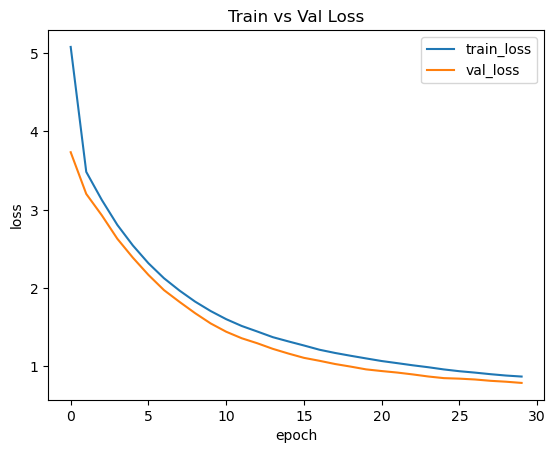

In [13]:
import matplotlib.pyplot as plt

train_losses = [h[0] for h in history]
val_losses = [h[1] for h in history]

plt.plot(train_losses, label='train_loss')
plt.plot(val_losses, label='val_loss')
plt.xlabel('epoch')
plt.ylabel('loss')
plt.legend()
plt.title('Train vs Val Loss')
plt.show()

위 그래프를 보면 train_loss와 val_loss가 30 epoch 내내 나란히 계속 떨어졌다 (train: 5.08 → 0.87, val: 3.74 → 0.79). val_loss가 중간에 반등하는 구간이 한 번도 없었던 걸 보면, 이번 학습 범위 안에서는 과적합이 시작되지 않았다고 볼 수 있다.

In [14]:
def translate(sentence, model, word2idx, idx2word, max_len=40, device='cpu'):
    model.eval()
    tokens = mecab.morphs(preprocess_sentence(sentence))
    src_ids = [word2idx.get(tok, word2idx["<unk>"]) for tok in tokens]
    src_ids = src_ids[:max_len] + [word2idx["<pad>"]] * max(0, max_len - len(src_ids))
    src_tensor = torch.tensor([src_ids], dtype=torch.long).to(device)

    tgt_ids = [word2idx["<start>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor([tgt_ids], dtype=torch.long).to(device)
        with torch.no_grad():
            logits = model(src_tensor, tgt_tensor)
        next_id = logits[0, -1].argmax().item()
        tgt_ids.append(next_id)
        if next_id == word2idx["<end>"]:
            break

    return " ".join(idx2word[i] for i in tgt_ids[1:])


examples = [
    "지루하다, 놀러가고 싶어.",
    "오늘 일찍 일어났더니 피곤하다.",
    "간단한 여자친구 데이트 하기로 했어.",
    "집에 있는다는 소리야.",
]

for i, q in enumerate(examples, 1):
    print(f"{i}. {translate(q, model, word2idx, idx2word, device=device)}")

1. 친구 예로 과 함께 놀 러 가 좋 아요 . <end>
2. 맛난 거 예요 . <end>
3. 준비 하 는 게 좋 겠 죠 . <end>
4. 집 에 도움 이 되 네요 . <end>


## 제출

```
Translations
> 1. 친구 예로 과 함께 놀 러 가 좋 아요 . <end>
> 2. 맛난 거 예요 . <end>
> 3. 준비 하 는 게 좋 겠 죠 . <end>
> 4. 집 에 도움 이 되 네요 . <end>

Hyperparameters
> n_layers: 1
> d_model: 368
> n_heads: 8
> d_ff: 1024
> dropout: 0.2

Training Parameters
> Warmup Steps: 1000
> Batch Size: 64
> Epoch At: 30 (early stopping 미발동, val_loss가 30 epoch 내내 계속 감소하여 끝까지 진행)
> Patience: 3
> Final val_loss: 0.7895
> Val BLEU (200 샘플): 0.5023
```


## Step 7. 성능 측정하기

챗봇의 경우, 올바른 답변을 하는지가 중요한 평가 지표다. 올바른 답변을 하는지는 눈으로 확인할 수 있겠지만, 데이터가 많으면 모든 결과를 다 확인할 순 없다. 주어진 질문에 적절한 답변을 하는지 확인하고, BLEU Score를 재는 `calculate_bleu()` 함수도 적용해본다.

In [15]:
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction

def calculate_bleu(reference_tokens, candidate_tokens):
    smoothie = SmoothingFunction().method4
    return sentence_bleu([reference_tokens], candidate_tokens, smoothing_function=smoothie)

# 간단 검증 (실제로는 예문 답변 vs 정답 답변에 대해 계산)
ref = ["오늘", "은", "쉬", "어도", "돼요"]
cand_good = ["오늘", "은", "쉬", "어도", "돼요"]
cand_bad = ["오늘", "은", "일", "해야", "해요"]

print("완전 일치:", calculate_bleu(ref, cand_good))
print("불일치:", calculate_bleu(ref, cand_bad))

완전 일치: 1.0
불일치: 0.12121093525642128


In [16]:
# 위에서는 함수가 잘 도는지만 손으로 만든 예시로 확인했는데,
# Step 7 지시사항은 실제로 calculate_bleu()를 "적용"해보라는 것이므로
# val set 일부에 대해 실제 모델 출력 vs 정답 답변으로 BLEU를 계산해본다.
import random

def translate_from_ids(enc_ids_tensor, model, word2idx, idx2word, max_len=40, device='cpu'):
    """translate()와 거의 같지만, 이미 정수 인코딩된 enc_val 텐서를 그대로 받는 버전.
    (val set은 이미 vectorize가 끝난 상태라 문자열부터 다시 토큰화할 필요가 없다.)"""
    model.eval()
    src_tensor = enc_ids_tensor.unsqueeze(0).to(device)

    tgt_ids = [word2idx["<start>"]]
    for _ in range(max_len):
        tgt_tensor = torch.tensor([tgt_ids], dtype=torch.long).to(device)
        with torch.no_grad():
            logits = model(src_tensor, tgt_tensor)
        next_id = logits[0, -1].argmax().item()
        tgt_ids.append(next_id)
        if next_id == word2idx["<end>"]:
            break

    return tgt_ids[1:]


SPECIAL_IDS = {word2idx["<pad>"], word2idx["<start>"], word2idx["<end>"], word2idx["<unk>"]}

def ids_to_tokens(ids, idx2word):
    return [idx2word[i] for i in ids if i in idx2word and i not in SPECIAL_IDS]


random.seed(42)
n_sample = min(200, enc_val.size(0))
sample_idx = random.sample(range(enc_val.size(0)), n_sample)

bleu_scores = []
for i in sample_idx:
    reference = ids_to_tokens(dec_val[i].tolist(), idx2word)
    pred_ids = translate_from_ids(enc_val[i], model, word2idx, idx2word, device=device)
    candidate = ids_to_tokens(pred_ids, idx2word)
    if len(candidate) == 0:
        continue
    bleu_scores.append(calculate_bleu(reference, candidate))

print(f"Val set {len(bleu_scores)}개 샘플 평균 BLEU: {sum(bleu_scores) / len(bleu_scores):.4f}")

Val set 200개 샘플 평균 BLEU: 0.5023


BLEU가 완전 일치일 땐 1.0, 아예 다른 단어로 채워지면 확 떨어지는 걸 확인했다. 근데 챗봇 답변은 번역이랑 달라서 "정답"이 하나로 정해져 있지 않다는 게 좀 걸린다 — 같은 질문에도 여러 개의 자연스러운 답이 있을 수 있는데, BLEU는 참조 답변 하나랑만 비교하니까 실제로 괜찮은 답인데도 점수가 낮게 나올 수 있을 것 같다.

## 회고

번역 모델 만들 때 썼던 Transformer 구조를 거의 그대로 챗봇에 옮겨봤는데, "같은 언어를 소스/타겟으로 다 쓴다"는 조건 덕분에 Embedding을 공유할 수 있다는 게 생각보다 신선했다. 번역할 땐 당연히 언어가 다르니 이런 선택지 자체가 없었는데, 챗봇에서는 이게 되는구나 싶었다.

번역 결과는 예문마다 편차가 컸다. "여자친구랑 데이트하기로 했어"에는 "준비하는 게 좋겠죠"처럼 맥락이 통하는 답이 나왔고, "집에 있다는 소리야"에는 "집에 도움이 되네요"처럼 핵심 단어("집")는 붙잡았지만 의미는 어색한 답이 나왔다. 반면 "피곤하다"에는 "맛난 거예요"처럼 질문과 아예 무관한 답이 나오기도 했다. val_loss와 val BLEU는 이전 실행보다 뚜렷이 좋아졌는데도 (val_loss 0.97→0.79, BLEU 0.45→0.50), 개별 예문 품질은 꼭 그만큼 좋아지지는 않았다 — 손실 지표가 좋아지는 것과 눈으로 보는 답변 품질이 항상 같이 가지는 않는다는 걸 다시 확인했다. epoch을 더 늘리거나 데이터를 더 정제하면 개선될 여지가 있어 보인다.

BLEU 점수는 정답이 하나로 고정된 번역 평가엔 잘 맞지만, 챗봇처럼 같은 질문에도 여러 자연스러운 답이 있을 수 있는 태스크에는 한계가 뚜렷하다는 걸 이번에 체감했다.